# Voxel Head Model

This notebook introduces `VoxelHeadModel`, an alternative to
`TwoSurfaceHeadModel` that represents the brain as a reduced set of
**voxels** rather than a triangulated cortex surface.  Voxel-based
reconstruction keeps depth information in the reconstructed image — a
useful property for high-density montages that reach the cortical and
subcortical volume.  See `40_image_reconstruction.ipynb` for the full
surface-based pipeline; this notebook focuses on what changes when the
brain is voxelised.

The pipeline mirrors the surface case:

1. Load a voxel head model from a standard atlas.
2. Snap optodes to the scalp; reduce voxels to those covered by the probe.
3. Run Monte-Carlo photon transport (or load precomputed fluence).
4. **Reduce voxels by fluence** — runs *between*
   MCX and `compute_sensitivity` so the resulting sensitivity matrix is
   small.
5. Compute the sensitivity matrix `Adot` directly on the kept voxels.
6. Optionally apply a final `reduce_voxels_to_sensitivity` for cleanup.
7. Reconstruct via `ImageRecon`.
8. Compare the depth distribution of voxel vs. surface brain targets.
9. Show how `voxel_to_vertex_brain` distorts spatially variant
   regularization (SVR) in the surface model.

In [1]:
# This cell sets up the environment when executed in Google Colab.
try:
    import google.colab
    get_ipython().system('curl -s https://raw.githubusercontent.com/ibs-lab/cedalion/dev/scripts/colab_setup.py -o colab_setup.py')
    get_ipython().run_line_magic('run', 'colab_setup.py')
except ImportError:
    pass

In [2]:
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import xarray as xr

import cedalion
import cedalion.data
import cedalion.dataclasses as cdc
import cedalion.dot as dot
import cedalion.dot.forward_model as fw
import cedalion.nirs
from cedalion import units

xr.set_options(display_expand_data=False);

## 1. Load a voxel head model

`get_standard_headmodel(model, kind="voxel")` returns a `VoxelHeadModel`
built from the same Colin27/ICBM152 segmentation masks that back the
surface variant.  The brain is meshed as voxels rather than as a
triangulated cortex; the scalp surface is reused from the atlas.

In [3]:
head = dot.get_standard_headmodel("colin27", kind="voxel")
print(head)

VoxelHeadModel(
  crs: ijk
  tissue_types: csf, gm, scalp, skull, wm
  brain voxels: 1607695 units: dimensionless
  scalp faces: 20096 vertices: 10050 units: dimensionless
  landmarks: 73
)


Compared to the surface variant, the brain attribute is now a
`cdc.Voxels` cloud rather than a mesh.  The sparse mapping
`voxel_to_vertex_brain` projects the full segmentation grid onto these
kept voxels — the columns are voxels here, not mesh vertices.  Code
that prefers a clearer name can use the alias
`voxel_to_voxel_brain`:

In [4]:
print("brain voxels:", head.brain.nvertices)
print("voxel_to_vertex_brain shape:", head.voxel_to_vertex_brain.shape)
print("alias property identity:", head.voxel_to_voxel_brain is head.voxel_to_vertex_brain)

brain voxels: 1607695
voxel_to_vertex_brain shape: (7109137, 1607695)
alias property identity: True


## 2. Probe-based reduction

Most montages cover only part of the head.  Brain voxels that no optode
can plausibly see can be dropped before any photon transport simulation.

In [5]:
rec = cedalion.data.get_fingertappingDOT()

# snap the recording's optode positions to the scalp surface
geo3d_snapped = head.align_and_snap_to_scalp(rec.geo3d)

# drop voxels far from any optode
head_ijk = head.reduce_voxels_to_probe(geo3d_snapped, max_dist=4 * units.cm)
print("after reduce_voxels_to_probe:", head_ijk.brain.nvertices, "voxels")

after reduce_voxels_to_probe: 921697 voxels


## 3. Use precomputed fluence

The full Monte-Carlo step (`ForwardModel.compute_fluence_mcx`) requires
an NVIDIA GPU and is omitted from the notebook output.  We use a
precomputed fluence HDF5 file instead.  Note the fluence file lives on
the *full* segmentation voxel grid — independent of which head model
(surface or voxel) consumes it.

In [6]:
fluence_fname = cedalion.data.get_precomputed_fluence("fingertappingDOT", "colin27")
print("fluence file:", fluence_fname)

fluence file: /Users/nilsharmening/Library/Caches/cedalion/dev/fluence_fingertappingDOT_colin27.h5


## 4. Fluence reducer

`reduce_voxels_by_fluence` reads the fluence file, computes per-voxel
$\sum_\text{optodes} |\text{fluence}|$ (max over wavelengths) and drops
voxels below `rel_threshold * max`. Runs *before* `compute_sensitivity`, so the
resulting `Adot` is small from the start.

In [7]:
head_ijk = head_ijk.reduce_voxels_by_fluence(fluence_fname, rel_threshold=1e-3)
print("after reduce_voxels_by_fluence:", head_ijk.brain.nvertices, "voxels")

after reduce_voxels_by_fluence: 501734 voxels


## 5. Compute sensitivity

`ForwardModel.compute_sensitivity` works exactly the same on a voxel
head model — the duck-typed attribute names match.  The resulting
`Adot` has dims `(channel, vertex, wavelength)` where `vertex` indexes
the kept voxels.

In [8]:
measurement_list = rec._measurement_lists["amp"]

fwm = fw.ForwardModel(head_ijk, geo3d_snapped, measurement_list)

with TemporaryDirectory() as tmp_dir:
    sens_path = Path(tmp_dir) / "sensitivity.nc"
    fwm.compute_sensitivity(fluence_fname, sens_path)
    Adot = cedalion.io.forward_model.load_Adot(sens_path)

print(Adot.dims, Adot.shape)
print("is_brain True count:", int(Adot.is_brain.sum()))

('channel', 'vertex', 'wavelength') (100, 511784, 2)
is_brain True count: 501734


## 6. Optional final cleanup

After `compute_sensitivity`, voxels with negligible total sensitivity
can be removed via an absolute threshold.

In [9]:
head_ijk_final = head_ijk.reduce_voxels_to_sensitivity(
    Adot, sensitivity_threshold=1e-4
)
print("after reduce_voxels_to_sensitivity:", head_ijk_final.brain.nvertices, "voxels")

after reduce_voxels_to_sensitivity: 238723 voxels


## 7. Image reconstruction

`ImageRecon` accepts `Adot` for either head model variant.  Below we
build a Tikhonov-only solver and reconstruct a synthetic optical-density
sample so the recovered image lands on the voxel `vertex` axis with a
known target.

The synthetic stimulus is generated by
`cedalion.sim.synthetic_hrf.build_spatial_activation_voxels`, the
voxel analogue of the surface
`build_spatial_activation`.  It drops a 3D Gaussian blob on the brain
voxels using Euclidean distance from one or more seed voxels and
returns a concentration-quantified `xr.DataArray` whose `vertex` axis
matches the brain rows of `Adot`, so it plugs straight into
`image_to_channel_space` and the solver.  The temporal HRF / stim-DataFrame
machinery in `cedalion.sim.synthetic_hrf` is generic and works on the
voxel output unchanged — see
`examples/augmentation/62_synthetic_hrfs_example.ipynb` for the surface
walkthrough that uses the same pipeline.

In [ ]:
import cedalion.sim.synthetic_hrf as synhrf

# Work in mm (RAS) so spatial_scale=1 cm and the seed selection are
# both physical lengths.  The vertex axis is preserved by
# apply_transform, so blob indices line up with Adot's brain rows.
head_ijk_ras = head_ijk.apply_transform(head_ijk.t_ijk2ras)
seed = int(
    head_ijk_ras.brain.kdtree.query(head_ijk_ras.landmarks.sel(label="C3"))[1]
)

# 3D Gaussian blob: peak 1 µM HbO, sigma = 1 cm, HbR = -0.4 * HbO.
blob = synhrf.build_spatial_activation_voxels(
    head_ijk_ras.brain,
    seed,
    spatial_scale=1 * units.cm,
    intensity_scale=1 * units.micromolar,
    hbr_scale=-0.4,
)

# Concentration -> OD in channel space (only the brain rows of Adot
# carry the activation; scalp rows would just contribute zeros).
Adot_brain = Adot.sel(vertex=Adot.is_brain)
spatial_chan = fw.image_to_channel_space(Adot_brain, blob, spectrum="prahl")

# Solver expects (channel, wavelength, time) OD.
od_synth = spatial_chan.expand_dims("time").assign_coords(time=[0.0])
od_synth.time.attrs["units"] = "s"

solver = dot.ImageRecon(Adot=Adot, recon_mode="conc", **dot.REG_TIKHONOV_ONLY)
image = solver.reconstruct(od_synth)
print(image.dims, image.shape)
hbo_peak = image.sel(chromo="HbO").pint.to("micromolar").max().pint.dequantify().item()
print(f"recovered HbO peak: {hbo_peak:.2e} µM")


## 8. Depth coverage: voxel vs. surface brain

Voxel reconstruction's main advantage over the surface variant is that
it preserves *depth* in the recovered image: every kept brain voxel is
an independent reconstruction target across the cortical and
subcortical volume, not a sample of a 2D cortical sheet.

To make this concrete we compute, for every brain element that
participates in the reconstruction, the distance to the nearest scalp
vertex.  We compare:

- the kept brain voxels of `head_ijk_final` (this notebook's pipeline);
- the brain-surface vertices of the matching `TwoSurfaceHeadModel`
  built from the same Colin27 atlas.

The surface variant's brain vertices all sit on the cortical sheet and
cluster in a narrow depth band; the voxel variant retains targets
deeper into the brain, where high-density montages can still deliver
some sensitivity.

VoxelHM   kept brain voxels (probe region):     238723  depth median  23.1 mm  max  39.6 mm
SurfaceHM brain vertices in same probe region:    8401  depth median  22.0 mm  max  40.0 mm
=> Voxel set has 28.4x more reconstruction targets in the same volume.


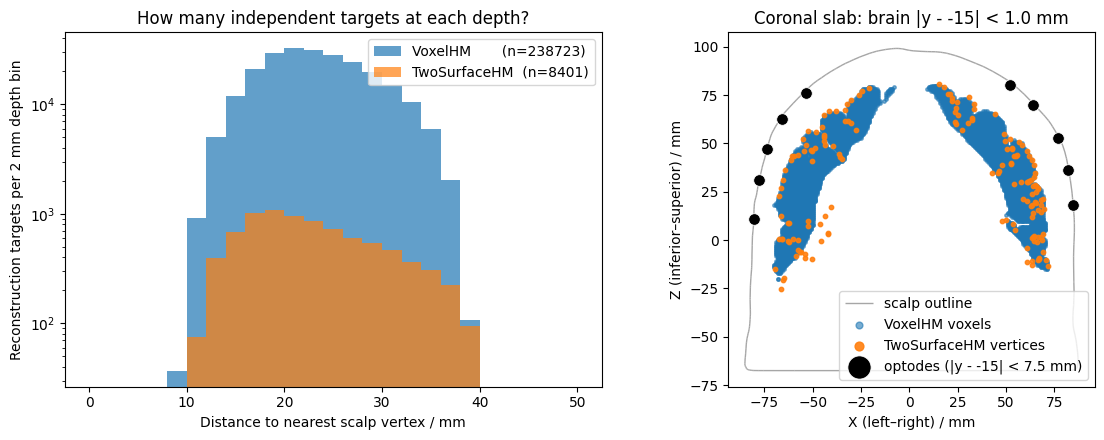

In [11]:
import matplotlib.pyplot as plt
import trimesh
from matplotlib.collections import LineCollection
from scipy.spatial import KDTree
from trimesh.intersections import mesh_plane

# work in millimetres (RAS)
voxel_head_ras = head_ijk_final.apply_transform(head_ijk_final.t_ijk2ras)
voxel_brain_mm = voxel_head_ras.brain.voxels
voxel_scalp_mm = voxel_head_ras.scalp.vertices.pint.to("mm").pint.dequantify().values

voxel_depth_mm, _ = KDTree(voxel_scalp_mm).query(voxel_brain_mm)

# matching surface head model from the same atlas
head_surface = dot.get_standard_headmodel("colin27", kind="surface")
surface_head_ras = head_surface.apply_transform(head_surface.t_ijk2ras)
surface_brain_mm = surface_head_ras.brain.vertices.pint.to("mm").pint.dequantify().values
surface_scalp_mm = surface_head_ras.scalp.vertices.pint.to("mm").pint.dequantify().values

surface_depth_mm, _ = KDTree(surface_scalp_mm).query(surface_brain_mm)

# Restrict the surface vertices to the same probe-accessible region the voxel
# pipeline retained, so the comparison is apples-to-apples (otherwise the
# surface set includes inaccessible deep medial / brain-stem vertices).
optodes_only = geo3d_snapped[geo3d_snapped.type != cdc.PointType.LANDMARK]
optode_pts_mm = (
    optodes_only.points.apply_transform(head.t_ijk2ras)
    .pint.to("mm").pint.dequantify().values
)
PROBE_RADIUS_MM = 40.0
near_probe = KDTree(optode_pts_mm).query(surface_brain_mm)[0] < PROBE_RADIUS_MM
surface_in_probe_mm = surface_brain_mm[near_probe]
surface_depth_in_probe = surface_depth_mm[near_probe]

n_voxel = len(voxel_depth_mm)
n_surface = len(surface_depth_in_probe)
ratio = n_voxel / n_surface

print(
    f"VoxelHM   kept brain voxels (probe region):     {n_voxel:>6d}  "
    f"depth median {np.median(voxel_depth_mm):5.1f} mm  "
    f"max {voxel_depth_mm.max():5.1f} mm"
)
print(
    f"SurfaceHM brain vertices in same probe region:  {n_surface:>6d}  "
    f"depth median {np.median(surface_depth_in_probe):5.1f} mm  "
    f"max {surface_depth_in_probe.max():5.1f} mm"
)
print(f"=> Voxel set has {ratio:.1f}x more reconstruction targets in the same volume.")

VOXEL_COLOR = "C0"      # blue — voxel set
SURFACE_COLOR = "C1"    # orange — surface set

# Side-by-side: counts vs depth (left) and a coronal-slice scatter (right)
fig, (ax_hist, ax_slice) = plt.subplots(1, 2, figsize=(12, 4.5))

bins = np.linspace(0, 50, 26)  # 2 mm bins
ax_hist.hist(
    voxel_depth_mm, bins=bins, alpha=0.7, color=VOXEL_COLOR,
    label=f"VoxelHM       (n={n_voxel})",
)
ax_hist.hist(
    surface_depth_in_probe, bins=bins, alpha=0.7, color=SURFACE_COLOR,
    label=f"TwoSurfaceHM  (n={n_surface})",
)
ax_hist.set_xlabel("Distance to nearest scalp vertex / mm")
ax_hist.set_ylabel("Reconstruction targets per 2 mm depth bin")
ax_hist.set_title("How many independent targets at each depth?")
ax_hist.set_yscale("log")
ax_hist.legend()

# Coronal slab: pick a thin slab around the median Y (anterior-posterior) of
# the kept voxels and plot (X, Z) for both sets.  The brain slab is kept very
# narrow so cortical folds remain readable; the optode slab is wider so all
# four optodes per hemisphere fall inside.
y_centre = np.median(voxel_brain_mm[:, 1])
BRAIN_SLAB_MM = 1.0
OPTODE_SLAB_MM = 7.5
v_in_slab = np.abs(voxel_brain_mm[:, 1] - y_centre) < BRAIN_SLAB_MM
s_in_slab = np.abs(surface_in_probe_mm[:, 1] - y_centre) < BRAIN_SLAB_MM
o_in_slab = np.abs(optode_pts_mm[:, 1] - y_centre) < OPTODE_SLAB_MM

# Scalp outline at this coronal plane
scalp_mesh_mm = trimesh.Trimesh(
    vertices=voxel_scalp_mm,
    faces=voxel_head_ras.scalp.mesh.faces,
    process=False,
)
scalp_segments = mesh_plane(
    scalp_mesh_mm,
    plane_normal=np.array([0.0, 1.0, 0.0]),
    plane_origin=np.array([0.0, float(y_centre), 0.0]),
)
ax_slice.add_collection(
    LineCollection(
        scalp_segments[:, :, [0, 2]],
        colors="gray", linewidths=1.0, alpha=0.7, label="scalp outline",
    )
)

# Draw voxels first (more numerous), surface vertices on top so both stay visible
ax_slice.scatter(
    voxel_brain_mm[v_in_slab, 0], voxel_brain_mm[v_in_slab, 2],
    s=6, alpha=0.6, color=VOXEL_COLOR, label="VoxelHM voxels",
)
ax_slice.scatter(
    surface_in_probe_mm[s_in_slab, 0], surface_in_probe_mm[s_in_slab, 2],
    s=10, alpha=0.9, color=SURFACE_COLOR, label="TwoSurfaceHM vertices",
)
ax_slice.scatter(
    optode_pts_mm[o_in_slab, 0], optode_pts_mm[o_in_slab, 2],
    s=70, color="black", edgecolors="white", linewidths=0.6, zorder=10,
    label=f"optodes (|y - {y_centre:.0f}| < {OPTODE_SLAB_MM:.1f} mm)",
)
ax_slice.set_xlabel("X (left–right) / mm")
ax_slice.set_ylabel("Z (inferior–superior) / mm")
ax_slice.set_title(
    f"Coronal slab: brain |y - {y_centre:.0f}| < {BRAIN_SLAB_MM:.1f} mm"
)
ax_slice.set_aspect("equal")
ax_slice.legend(loc="lower right", markerscale=2)

fig.tight_layout()

**What to take away from the two panels:**

- *Left, log-scale count histogram.* Across **every** depth bin the voxel
  set has roughly an order of magnitude more reconstruction targets than
  the surface set in the same probe region. The surface mesh is a 2D
  cortical sheet that gets sparser at greater depths only because the
  sheet curves out of the probe's reach; the voxel cloud fills the
  intervening volume.

- *Right, coronal-slice scatter.* The black markers show the optodes
  sitting in (or close to) the same coronal slab. Below them, the
  surface vertices trace a thin folded cortical ribbon, while the voxel
  set fills the gray + shallow-white matter the probe can illuminate.
  For any given lateral position under the montage, the voxel pipeline
  hands the inverse problem **multiple independent targets stacked along
  depth**, where the surface pipeline collapses everything onto a single
  cortical sample.

**Why this matters for group analyses in MNI space.** Because every
voxel carries an exact 3D coordinate (in `ijk`, easily transformed to
RAS / MNI152 via the head model's affine), a voxel reconstruction can
be projected straight into a common atlas space. Per-subject voxel maps
can then be averaged or contrasted at matching MNI coordinates without
relying on surface-to-surface registration. Depth is preserved through
the transform, so two subjects' activations are aligned not just along
the cortical sheet but also through the cortical column. The surface
variant, by contrast, ties results to the subject's mesh topology and
offers only parcel-level averaging when going group-level.

This is what "preserving depth in the reconstructed image" means in
practice: with real OD data the voxel pipeline can recover
depth-resolved HbO/HbR profiles, and those profiles transfer cleanly
into MNI space for group comparison.

## 9. Why SVR underperforms on a TSHM brain

Spatially variant regularization (SVR) is the standard depth-compensation
trick in DOT image reconstruction. Inside `cedalion.dot.ImageRecon` it
appears as a per-target column scaling of the sensitivity matrix
(see `_calculate_prior_R` in `src/cedalion/dot/image_recon.py:1245`):

$$R_j \;=\; \frac{1}{\|A[:,j]\|^{2} \;+\; \alpha_{\text{spatial}}\,\max_{j}\|A[:,j]\|^{2}}$$

Each reconstruction target gets a weight that is inversely proportional
to its own sensitivity-energy, so deep targets — which have low
sensitivity and would otherwise be drowned out by shallow ones — are
boosted back into the recovered image.

The catch: in `TwoSurfaceHeadModel` the per-target column $A[:, v]$ is
not a per-voxel quantity. Every brain voxel is assigned to its single
nearest surface vertex by KDTree (`src/cedalion/dot/utils.py:48`), and
the surface sensitivity at vertex *v* is the **sum** of voxel
sensitivities over all voxels mapped to *v*
(`src/cedalion/dot/forward_model.py:516`,
`pertubation @ voxel_to_vertex_brain`). That summation distorts what
SVR sees in two ways that voxel reconstruction sidesteps:

1. **Summation buries deep voxels.** A vertex's $\|A[:,v]\|^{2}$ is
   dominated by whichever mapped voxel has the highest sensitivity —
   typically a shallow one. Every deep voxel mapped to the same vertex
   silently inherits that single SVR weight and can no longer be
   re-weighted independently, which is precisely the job SVR was
   designed to do.
2. **Voxel-per-vertex counts are driven by cortical folding, not by
   physics.** Sulcal walls (concave) capture many neighbouring voxels
   per vertex; gyral crowns (convex) capture few. SVR's denominator
   therefore varies with mesh topology, not with tissue depth.

The next cell makes both effects visible directly from
`voxel_to_vertex_brain`, without running any reconstruction.

In [ ]:
from scipy.spatial import KDTree

import cedalion.geometry.segmentation as segm

# --- 1. voxel-to-vertex mapping (full segmentation grid -> surface vertices)
M = head_surface.voxel_to_vertex_brain.tocsc()
nvertices = M.shape[1]

# voxels-per-vertex = column nnz (each cell row has at most one nonzero)
n_voxels_per_vertex = np.diff(M.indptr).astype(int)

# --- 2. depth (mm to nearest scalp vertex) for *every* mapped voxel,
#        computed once on the full ijk grid, then indexed per vertex.
seg = head_surface.segmentation_masks
grid_ijk = segm.cell_coordinates(seg.isel(segmentation_type=0).values, flat=True)
grid_ras = grid_ijk.points.apply_transform(head_surface.t_ijk2ras)
grid_mm = grid_ras.pint.to("mm").pint.dequantify().values  # (ncells, 3)

scalp_tree = KDTree(surface_scalp_mm)

M_coo = M.tocoo()
mapped_cell_ids = M_coo.row
mapped_vert_ids = M_coo.col
mapped_depth_mm, _ = scalp_tree.query(grid_mm[mapped_cell_ids])

# group depths per vertex (vectorised: sort by vertex, then segment)
order = np.argsort(mapped_vert_ids, kind="stable")
v_sorted = mapped_vert_ids[order]
d_sorted = mapped_depth_mm[order]
unique_v, idx_start, counts = np.unique(
    v_sorted, return_index=True, return_counts=True
)

depth_min = np.full(nvertices, np.nan)
depth_max = np.full(nvertices, np.nan)
depth_spread = np.full(nvertices, np.nan)
for v, s, c in zip(unique_v, idx_start, counts):
    seg_d = d_sorted[s : s + c]
    depth_min[v] = seg_d.min()
    depth_max[v] = seg_d.max()
    depth_spread[v] = seg_d.max() - seg_d.min()

# --- 3. per-vertex aggregated sensitivity (proxy for what SVR sees in TSHM).
# We use the voxel-space `Adot` from Section 6 (kept brain voxels) and group
# each kept brain voxel by its nearest TSHM brain vertex. The aggregate
# Σ_j ‖A_vox[:, j]‖² approximates the surface ‖A[:, v]‖² that drives SVR
# (the cross-terms in (Σ A)² are dropped — they only sharpen the same trend).
A_brain = Adot.sel(vertex=Adot.is_brain.values).values  # (chan, n_brain_vox, wl)
voxel_energy = (A_brain ** 2).sum(axis=(0, 2))  # (n_brain_vox,)

# Voxel coords aligned with Adot's vertex axis. Adot was built from head_ijk
# (post-fluence-reduction); head_ijk_final dropped further low-sensitivity
# voxels but Adot itself is unchanged, so we use head_ijk's brain.voxels here.
adot_brain_mm = head_ijk.apply_transform(head_ijk.t_ijk2ras).brain.voxels

brain_tree = KDTree(surface_brain_mm)
_, kept_voxel_to_vert = brain_tree.query(adot_brain_mm)

vertex_sensitivity = np.zeros(nvertices)
np.add.at(vertex_sensitivity, kept_voxel_to_vert, voxel_energy)

# --- 4. restrict to the probe region (reuses Section 8's near_probe mask)
probe_count = n_voxels_per_vertex[near_probe]
probe_spread = depth_spread[near_probe]
probe_sens = vertex_sensitivity[near_probe]

# Drop probe-region vertices with no mapped voxels OR no aggregated sensitivity
ok = np.isfinite(probe_spread) & (probe_count > 0) & (probe_sens > 0)
probe_count = probe_count[ok]
probe_spread = probe_spread[ok]
probe_sens = probe_sens[ok]

med_count = int(np.median(probe_count))
p95_count = int(np.percentile(probe_count, 95))
med_spread = float(np.median(probe_spread))
sens_med = float(np.median(probe_sens))
sens_p5 = float(np.percentile(probe_sens, 5))
sens_p95 = float(np.percentile(probe_sens, 95))

print(f"probe-region surface vertices kept: {probe_count.size:>5d}")
print(f"voxels mapped per vertex      median {med_count:>3d}  p95 {p95_count:>3d}  "
      f"min {probe_count.min():>3d}  max {probe_count.max():>3d}")
print(f"depth spread per vertex / mm  median {med_spread:5.1f}  "
      f"max {probe_spread.max():5.1f}")
print(f"vertex sensitivity Σ‖A‖²      median {sens_med:.2e}  "
      f"p5 {sens_p5:.2e}  p95 {sens_p95:.2e}")

# --- 5. Plot
fig, (ax_h, ax_s) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: voxels-per-vertex histogram (log x for visibility of the long tail)
bins_count = np.logspace(0, np.log10(max(probe_count.max(), 2)) + 0.05, 30)
ax_h.hist(probe_count, bins=bins_count, color=SURFACE_COLOR, alpha=0.85)
ax_h.axvline(med_count, color="k", linestyle="--", linewidth=1.0,
             label=f"median = {med_count}")
ax_h.axvline(p95_count, color="k", linestyle=":", linewidth=1.0,
             label=f"p95 = {p95_count}")
ax_h.set_xscale("log")
ax_h.set_xlabel("Voxels mapped to a single surface vertex")
ax_h.set_ylabel("Number of probe-region surface vertices")
ax_h.set_title("How many voxels feed each vertex's SVR weight?")
ax_h.legend()

# Right: scatter of count vs depth-spread, coloured by aggregated sensitivity
log_probe_sens = np.log10(probe_sens)
sc = ax_s.scatter(
    probe_count, probe_spread, c=log_probe_sens,
    cmap="jet", vmin=np.log10(sens_p5), vmax=np.log10(sens_p95),
    s=10, alpha=0.65, edgecolors="none",
)
ax_s.axhline(med_spread, color="k", linestyle="--", linewidth=1.0,
             label=f"median spread = {med_spread:.1f} mm")
ax_s.set_xscale("log")
ax_s.set_xlabel("Voxels mapped to vertex (log scale)")
ax_s.set_ylabel("Depth spread of mapped voxels / mm")
ax_s.set_title("Per-vertex sensitivity vs. count and spread")
cbar = fig.colorbar(sc, ax=ax_s)
cbar.set_label(r"$\log_{10}$ " + r"($\sum_j \|A[:,j]\|^2$ / mm$^2$)")
ax_s.legend(loc="upper left")

fig.tight_layout()

**What to read off the two panels.**

- *Left, voxels-per-vertex histogram.* Within the probe region, the
  number of voxels feeding a single surface vertex spans more than two
  orders of magnitude. The typical vertex collects a few dozen voxels;
  the long right-hand tail — vertices that sit inside sulcal folds or
  far from any other cortical-surface vertex — collects hundreds. SVR's
  denominator $\|A[:,v]\|^{2}$ is built from this count-dependent
  sum, so the regularization weight assigned to a vertex is set partly
  by the local cortical folding rather than by the physics of light
  transport.

- *Right, count vs depth-spread, coloured by per-vertex sensitivity.*
  The two structural axes — how many voxels are mapped to a vertex and
  how deep the deepest of them lies — already show a clear coupling
  (more mapped voxels → wider depth spread). The colour layer adds the
  quantity SVR actually consumes: aggregated voxel sensitivity at the
  vertex (proxied by $\sum_j \|A[:,j]\|^2$ over the kept voxels
  mapped to that vertex; the exact TSHM expression
  $\|\sum_j A[:,j]\|^2$ has cross-terms but the same qualitative
  shape). Per-vertex sensitivity spans roughly **eight orders of
  magnitude** in this run, far more than count or depth-spread, and is
  scattered across both axes — gyral-style low-count vertices range
  from very low to very high sensitivity (depending on whether they
  sit under an optode), and sulcal-style high-count vertices likewise.
  In other words, the count tells you almost nothing about the SVR
  weight; the SVR weight is set by an opaque mixture of folding
  topology (count), depth aggregation (spread), and lateral probe
  geometry (sensitivity), all collapsed onto one number per vertex.

In voxel space none of this collapsing happens: every voxel is its own
column of *A*, so SVR sees the raw per-voxel sensitivity-energy and
weights each target on its own merits. SVR can then do exactly what it
was designed to do — pull activation back to its true depth. The
trade-off, already noted above, is that SVR on voxels is more
parameter-sensitive: an overly aggressive `alpha_spatial` will
over-amplify deep voxels and dredge up noise.